(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64

label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64
학습 데이터: (4457, 5000)
테스트 데이터: (1115, 5000)
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



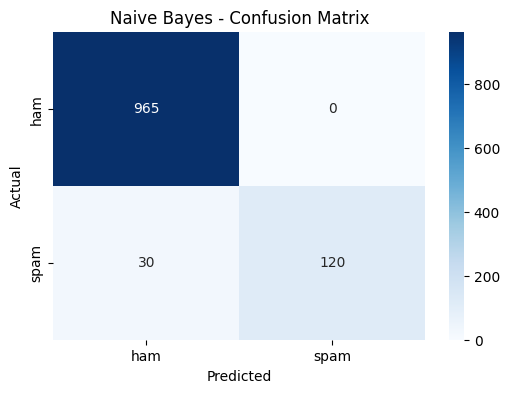

=== 나이브 베이즈 ===
정확도: 0.9731

=== 로지스틱 회귀 ===
정확도: 0.9587

=== SVM ===
정확도: 0.9794
메시지: Congratulations! You've won a free iPhone. Click here now!
결과: SPAM
스팸 확률: 53.24%

메시지: Hey, are we still meeting for lunch tomorrow?
결과: HAM
스팸 확률: 0.23%

메시지: URGENT! Your account will be closed. Call 0800-123-456 immediately
결과: SPAM
스팸 확률: 65.99%

메시지: Can you pick up some milk on the way home?
결과: HAM
스팸 확률: 0.64%



In [9]:
# 나이브 베이즈 실습

# 스팸 메세지 분류기
# 데이터셋 : https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset?select=spam.csv

# 나이브 (Naive) : 순진하다.
# 지각 하는 학생 VS 숙제 안해오는 학생
# 현실 : 보통 지각하는애가 숙제를 안해올 확률도 높다.
# 나이브베이즈 : 지각 과 숙제 는 별개야 (각각 독립적으로 계산한다.)

# 해당 단어가 들어 있으면 스팸 예측
# 수식
# P(스팸 | 단어들) = P(단어들 | 스팸) × P(스팸) / P(단어들)
# P(스팸 | 단어들) =
# P(단어들 | 스팸) × P(스팸) / P(단어들)
# 스팸일 확률을 구하고 싶어 P(스팸 | 단어들)  =
# P(단어들 | 스팸) 스팸에서 이 단어가 나올확률  *× P(스팸) 전체 메일 중 스팸 비중
# / P(단어들) 이 단어 들이 나올 전체 확률

# 해독이 빠르다. 텍스트 분류에 강하다. (스팸 / 감성분석 / 뉴스 등)
# 문맥 파악이 약하다.(단어 간 관계를 무시) , 좋다 ↔ 안좋다를 구분 못할 수 있다.

# =============라이브러리 호출============================
import pandas as pd

# 숫자 / 배열 계산
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터를 학습용 / 테스트용 으로 분리
from sklearn.model_selection import train_test_split

# 문장을 숫자로 바꿔주는 (가중치 가 맞는표현. 이진데이터가 아님 (소숫점 데이터). 0.xx같은 소수점 도 등장함.)
from sklearn.feature_extraction.text import TfidfVectorizer

# 나이브 베이즈 모델 가져옴
from sklearn.naive_bayes import MultinomialNB

# 비교하기 위한 모델들을 가져옴 (로지스틱회귀, ㅣSVM)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,  # 혼동행렬
    classification_report,  # 모델의 정확도
)
import re  # 텍스트에서 특정 패턴을 찾기 위한 정규표현식
import string  # 특문 처리

# ===========================================================

# =============데이터 로드 (코랩에 csv 파일 업로드 필요.) ============================
# csv 를 읽어 df 에 저장 , 특수인코딩 지정
df = pd.read_csv("spam.csv", encoding="latin-1")
# v1, v2 컬럼을 제하고 나머지 컬럼 버리기
df = df[["v1", "v2"]]
# v1, v2 컬럼 이름을 지정해줌
df.columns = ["label", "message"]
# 데이터가 몇행 X 몇열 인지 확인 (5,572 개의 데이터셋)
print(df.shape)
# 잘 업로드 되었는지 상위 5 개 만 미리보기 확인
df.head()


# ============= 데이터 탐색 (EDA) ========================

# ham , spam 의 개수 세기
print(df["label"].value_counts())
print()
# 비율로 표현하기
print(df["label"].value_counts(normalize=True))
# =============== 출력화면 ==============================
# (5572, 2)
# label
# ham     4825  # 정상
# spam     747  # 스팸
# Name: count, dtype: int64

# label
# ham     0.865937  # 정상 86%
# spam    0.134063  # 스팸 13%
# Name: proportion, dtype: float64


# ============= 전처리 (label 을 숫자로 변환하기)===================================
# 라벨 변환: ham=0, spam=1
# 컴퓨터는 ham, spam 단어를 못읽기 때문에 0과 1 로 변환해줌
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# 학습/테스트 분리
# (랜덤시드) 데이터 난수고정, 80% 학습용데이터 / 20% 테스트용 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label"], test_size=0.2, random_state=42
)

# TF-IDF 벡터화 (이 단어가 얼마나 중요한지? 숫자로 바꿔 주는 것)
# TF -IDF 도구세팅.
# stop_words="english : the, is , a 등 의미업는 (관사) 제거
# max_features=5000 : 중요단어 5,000개 만 사용
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

# 학습데이터로 단어의 기준을 학습(fit) + 변환(transform) 을 동시작업
X_train_tfidf = tfidf.fit_transform(X_train)
# 테스트 데이터는 변환만 한다 (공부 한 것으로 문제만 푼다.)
X_test_tfidf = tfidf.transform(X_test)


print("학습 데이터:", X_train_tfidf.shape)
print("테스트 데이터:", X_test_tfidf.shape)

# ============전처리 결과==================

# (...)
# label
# ham     0.865937
# spam    0.134063
# Name: proportion, dtype: float64
# 학습 데이터: (4457, 5000)
# 테스트 데이터: (1115, 5000)
# =======================================

# ============= 모델 학습 ================================
# 나이브 베이즈

# 나이브 베이즈 모델 생성
nb_model = MultinomialNB()
# 학습 데이터로 훈련시키기 (패턴을 배우는 과정. ex. 이런단어는 스팸임)
nb_model.fit(X_train_tfidf, y_train)

# 테스트 데이터로 예측하기 : 스팸일까 아닐까?
y_pred = nb_model.predict(X_test_tfidf)

# 성능 확인 (예측한 결과 / 정답을 비교 해서 출력하기)
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

# 학습결과 =======================================================
# (....)
#               precision    recall  f1-score   support

#          ham       0.97      1.00      0.98       965
#         spam       1.00      0.80      0.89       150

#     accuracy                           0.97      1115
#    macro avg       0.98      0.90      0.94      1115
# weighted avg       0.97      0.97      0.97      1115

# ============= 혼동행렬 시각화 ===========================
# 정답 VS. 예측 비교표 만들기
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))  # 가로 6, 세로 4
# *
# nnot=True : 칸에 숫자를  표시.
# fmt="d" : 정수로 표시
# cmap="Blues", :  색상
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"],
)
# 그래프에 이름 붙이기 (label, title, 시각화 출력)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes - Confusion Matrix")
plt.show()


#  시각화 그래프 출력


# ============= 모델 비교 ================================
# 로지스틱 회귀 -------------------------------------
# 모델생성
lr_model = LogisticRegression(max_iter=1000)
# 학습
lr_model.fit(X_train_tfidf, y_train)
# 예측
lr_pred = lr_model.predict(X_test_tfidf)

# SVM (Support Vector Machine) 데이터 사이 깔끔한 경계선을 그어 나누는 모델---------------
# SVM 이 큰 카테고리
# SVC → 분류용 (Classification)
# SVR → 회귀용 (Regression)

# 모델 생성
svm_model = SVC(kernel="linear")
# 학습
svm_model.fit(X_train_tfidf, y_train)
# 예측
svm_pred = svm_model.predict(X_test_tfidf)

# ============성능 비교=============================
# 나이브 베이즈 VS. 로지스틱 회귀 VS. SVM 비교하기 (소수점 4쨰자리 까지 정확도 출력)

print("=== 나이브 베이즈 ===")
print(f"정확도: {accuracy_score(y_test, y_pred):.4f}\n")

print("=== 로지스틱 회귀 ===")
print(f"정확도: {accuracy_score(y_test, lr_pred):.4f}\n")

print("=== SVM ===")
print(f"정확도: {accuracy_score(y_test, svm_pred):.4f}")

# === 나이브 베이즈 ===
# 정확도: 0.9731    97 %

# === 로지스틱 회귀 ===
# 정확도: 0.9587    95 %

# === SVM ===
# 정확도: 0.9794    97 %


# ============= 실제 메시지 테스트 ========================


# 메세지 입력시 스팸인지 아닌지 판별해 주는 함수 생성
def predict_spam(message):
    # 입력 한 메세지를 숫자로 변환 (transform 만)
    msg_tfidf = tfidf.transform([message])
    # 나이브 모델로 예측 . [0] : 첫번째 값 꺼낼것.
    result = nb_model.predict(msg_tfidf)[0]
    # 스팸일 확률을 구함. (predict : 결과만 / predict_proba : 확률까지)
    prob = nb_model.predict_proba(msg_tfidf)[0]
    # 1 이면 spam 아니면 정상 알려주기
    label = "SPAM" if result == 1 else "HAM"
    print(f"메시지: {message}")
    print(f"결과: {label}")
    print(f"스팸 확률: {prob[1]:.2%}\n")


# ==================== 테스트 ========================================
# 영어로 학습을 했기 때문에 한글로 문구를 넣으면
# 제대로 감지 못해 전혀 다른결과가 나올 수 있음.
# 한글 데이터셋 이면 학습 할 수 있음 .
# 나이브베이즈(기초) / KOBERT , SBERT  한국어 잘 이해하는 모델 (업그레이드)

# --------------------------------------
# 축하합니다! 무료 아이폰 당첨! (spam)
predict_spam("Congratulations! You've won a free iPhone. Click here now!")
# 내일 점심 만나는거지?(ham)
predict_spam("Hey, are we still meeting for lunch tomorrow?")
# 긴급! 계정 폐쇄!(spam)
predict_spam("URGENT! Your account will be closed. Call 0800-123-456 immediately")
# 집가는길에 우유 사다줄수있어?(ham)
predict_spam("Can you pick up some milk on the way home?")
